# AI-Art Forensics_4: Explainability

## Cell 0 — Imports, constants, load everything (run first every session)

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm.notebook import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.2)
COLORS = {
    'human'              : '#4C9BE8',
    'latent_diffusion'   : '#E87C4C',
    'standard_diffusion' : '#5CB85C'
}
OUT_DIR = '/kaggle/working'
FIG_DIR = f'{OUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)

EMBED_PATH = None
META_PATH = None

for root, dirs, files in os.walk('/kaggle/input'):
    if 'embeddings.npy' in files and 'metadata.csv' in files:
        EMBED_PATH = os.path.join(root, 'embeddings.npy')
        META_PATH = os.path.join(root, 'metadata.csv')
        break

if EMBED_PATH is None:
    print('ERROR: Could not find embeddings.npy and metadata.csv.')
    print('\nAvailable Kaggle inputs:')
    for root, dirs, files in os.walk('/kaggle/input'):
        print(root)
        for file in files:
            print('   ', file)
else:
    print(f'Embeddings path: {EMBED_PATH}')
    print(f'Metadata path:   {META_PATH}')
    
E    = np.load(EMBED_PATH)
meta = pd.read_csv(META_PATH)

meta['style'] = meta['style'].str.replace('-', '_')

print(f'Embeddings : {E.shape}')
print(f'Metadata   : {len(meta):,} rows')

train_mask = meta['split'] == 'train'
test_mask  = meta['split'] == 'test'

X_train = E[train_mask];  y_train = meta.loc[train_mask, 'label'].values
X_test  = E[test_mask];   y_test  = meta.loc[test_mask,  'label'].values
src_test = meta.loc[test_mask, 'source'].values
sty_test = meta.loc[test_mask, 'style'].values

clf = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                          random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_proba = clf.predict_proba(X_test)[:, 1]   
y_pred  = clf.predict(X_test)
print(f'Classifier retrained. Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')

Embeddings path: /kaggle/input/notebooks/merjendursunova/clip-embedding-extraction/embeddings.npy
Metadata path:   /kaggle/input/notebooks/merjendursunova/clip-embedding-extraction/metadata.csv
Embeddings : (185015, 512)
Metadata   : 185,015 rows
Classifier retrained. Accuracy: 99.49%


## CLIP Attention Maps

In [2]:
import torch
import torch.nn.functional as F

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
!pip install -q git+https://github.com/openai/CLIP.git
import clip

model, preprocess = clip.load('ViT-B/32', device=DEVICE)
model.eval()

print('CLIP loaded.')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00


100%|███████████████████████████████████████| 338M/338M [00:12<00:00, 28.4MiB/s]


CLIP loaded.


In [4]:
import torch
import torch.nn.functional as F

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

import clip

model, preprocess = clip.load('ViT-B/32', device=DEVICE)

model = model.float()
model.eval()

print('CLIP loaded.')
print('Model dtype:', next(model.parameters()).dtype)

Device: cuda
CLIP loaded.
Model dtype: torch.float32


In [5]:
img_path = meta.iloc[0]['path']

test_img = Image.open(img_path).convert('RGB')
test_tensor = preprocess(test_img).unsqueeze(0).to(DEVICE)
test_tensor.requires_grad_(True)

features = model.visual(test_tensor)

print("Input:", test_tensor.shape, test_tensor.dtype)
print("Output:", type(features), features.shape)

Input: torch.Size([1, 3, 224, 224]) torch.float32
Output: <class 'torch.Tensor'> torch.Size([1, 512])


In [6]:

model = model.float()

In [7]:

print("Model dtype:", next(model.parameters()).dtype)

Model dtype: torch.float32


In [8]:
def get_saliency_map(img_path, model, preprocess, device):

    image = Image.open(img_path).convert('RGB')

    img_tensor = preprocess(image).unsqueeze(0).to(device)
    img_tensor.requires_grad_(True)

    model.zero_grad(set_to_none=True)

    features = model.visual(img_tensor)

    score = features.norm()
    score.backward()

    if img_tensor.grad is None:
        raise RuntimeError("No gradient was produced.")

    saliency = img_tensor.grad.detach().abs().squeeze(0)
    saliency = saliency.max(dim=0)[0]

    saliency = (
        (saliency - saliency.min()) /
        (saliency.max() - saliency.min() + 1e-8)
    )

    return saliency.cpu().numpy()

In [9]:
test_map = get_saliency_map(
    meta.iloc[0]['path'],
    model,
    preprocess,
    DEVICE
)

print("Saliency shape:", test_map.shape)
print("Min:", test_map.min())
print("Max:", test_map.max())

Saliency shape: (224, 224)
Min: 0.0
Max: 0.99999994


In [10]:
import time

img_path = meta.iloc[0]['path']

print("Starting...", flush=True)
start = time.time()

test_map = get_saliency_map(
    img_path,
    model,
    preprocess,
    DEVICE
)

print(f"Finished in {time.time() - start:.2f} seconds", flush=True)
print("Shape:", test_map.shape)

Starting...
Finished in 0.04 seconds
Shape: (224, 224)


Processing 1/3: Human - impressionism
  Saliency done in 0.049s
Processing 1/3: AI (Latent Diff.) - impressionism
  Saliency done in 0.046s
Processing 1/3: AI (Std. Diff.) - impressionism
  Saliency done in 0.055s
Processing 2/3: Human - surrealism
  Saliency done in 0.045s
Processing 2/3: AI (Latent Diff.) - surrealism
  Saliency done in 0.051s
Processing 2/3: AI (Std. Diff.) - surrealism
  Saliency done in 0.053s
Processing 3/3: Human - baroque
  Saliency done in 0.046s
Processing 3/3: AI (Latent Diff.) - baroque
  Saliency done in 0.046s
Processing 3/3: AI (Std. Diff.) - baroque
  Saliency done in 0.057s
All images processed. Rendering figure...
Figure saved.


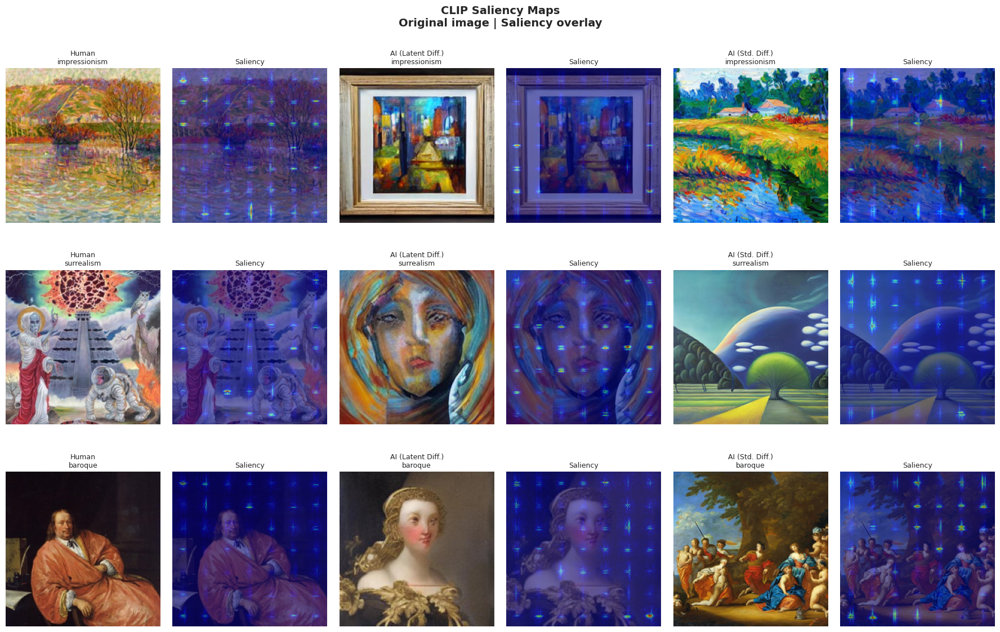

DONE.


In [11]:
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

styles_to_show = ['impressionism', 'surrealism', 'baroque']
sources = ['human', 'latent_diffusion', 'standard_diffusion']
src_labels = ['Human', 'AI (Latent Diff.)', 'AI (Std. Diff.)']

fig, axes = plt.subplots(
    3, 6,
    figsize=(18, 12)
)

fig.suptitle(
    'CLIP Saliency Maps\n'
    'Original image | Saliency overlay',
    fontsize=14,
    fontweight='bold'
)

for row, style in enumerate(styles_to_show):

    for col, (src, lbl) in enumerate(zip(sources, src_labels)):

        print(f"Processing {row+1}/3: {lbl} - {style}", flush=True)

        subset = meta[
            (meta['style'] == style) &
            (meta['source'] == src) &
            (meta['split'] == 'test')
        ]

        ax_orig = axes[row, col * 2]
        ax_attn = axes[row, col * 2 + 1]

        if len(subset) == 0:
            ax_orig.axis('off')
            ax_attn.axis('off')
            print("  No image found.", flush=True)
            continue

        row_data = subset.sample(1, random_state=42).iloc[0]
        img_path = row_data['path']

        
        start = time.time()

        attn_map = get_saliency_map(
            img_path,
            model,
            preprocess,
            DEVICE
        )

        print(
            f"  Saliency done in {time.time() - start:.3f}s",
            flush=True
        )

      
        img = Image.open(img_path).convert('RGB').resize((224, 224))

       
        ax_orig.imshow(img)
        ax_orig.set_title(
            f'{lbl}\n{style}',
            fontsize=9
        )
        ax_orig.axis('off')

        ax_attn.imshow(img)
        ax_attn.imshow(
            attn_map,
            cmap='jet',
            alpha=0.55,
            vmin=0,
            vmax=1
        )
        ax_attn.set_title(
            'Saliency',
            fontsize=9
        )
        ax_attn.axis('off')

plt.tight_layout()

print("All images processed. Rendering figure...", flush=True)

plt.savefig(
    f'{FIG_DIR}/09_saliency_maps.png',
    dpi=120,
    bbox_inches='tight'
)

print("Figure saved.", flush=True)

plt.show()

print("DONE.", flush=True)

## Confidence Analysis

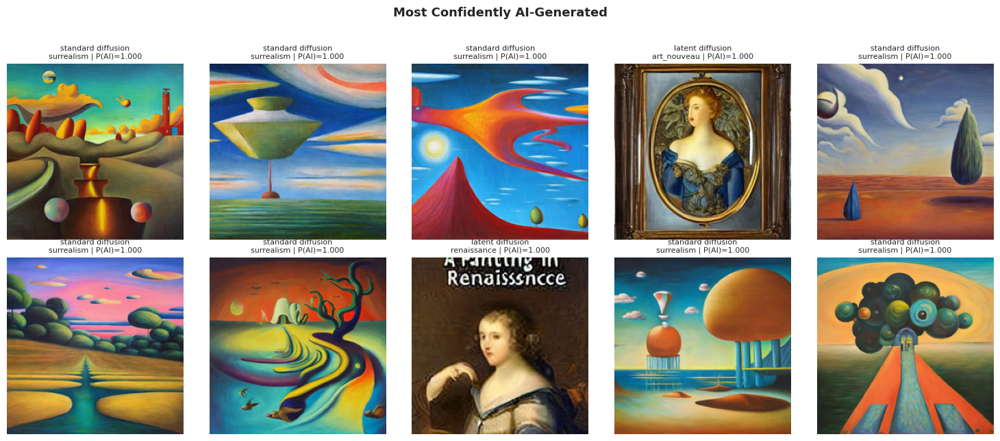

Saved → /kaggle/working/figures/10_most_confident_ai.png


In [12]:
def show_image_grid(paths, titles, suptitle, save_path, n_cols=5):
    n_rows = (len(paths) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 3, n_rows * 3.2))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, path, title in zip(axes, paths, titles):
        try:
            img = Image.open(path).convert('RGB').resize((224, 224))
            ax.imshow(img)
        except Exception:
            ax.set_facecolor('#eee')
        ax.set_title(title, fontsize=8)
        ax.axis('off')
    for ax in axes[len(paths):]:
        ax.axis('off')
    fig.suptitle(suptitle, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


test_meta = meta[test_mask].copy().reset_index(drop=True)
test_meta['p_ai']      = y_proba
test_meta['predicted'] = y_pred
test_meta['correct']   = (y_pred == y_test)
test_meta['distance']  = np.abs(y_proba - 0.5)   

N_SHOW = 10


top_ai = test_meta[(test_meta['label'] == 1) &
                   (test_meta['correct'])].nlargest(N_SHOW, 'p_ai')
show_image_grid(
    top_ai['path'].tolist(),
    [f"{r.source.replace('_',' ')}\n{r.style} | P(AI)={r.p_ai:.3f}"
     for _, r in top_ai.iterrows()],
    'Most Confidently AI-Generated',
    f'{FIG_DIR}/10_most_confident_ai.png'
)

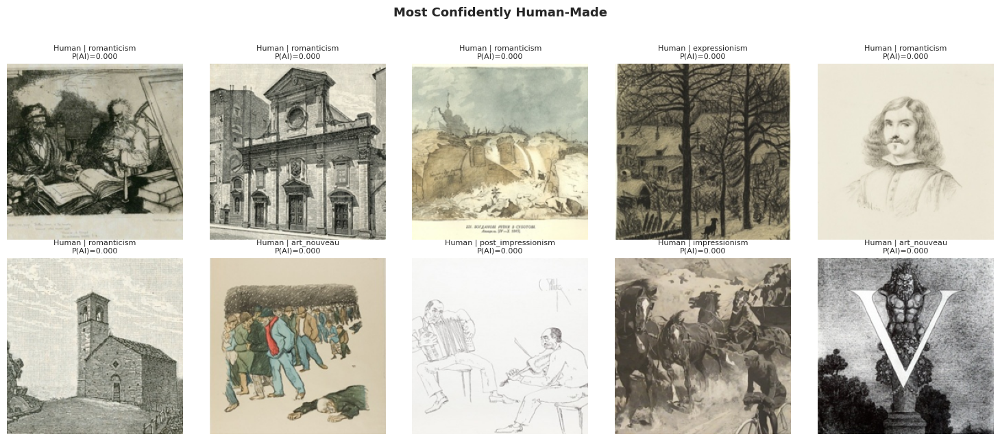

Saved → /kaggle/working/figures/11_most_confident_human.png


In [13]:
top_human = test_meta[(test_meta['label'] == 0) &
                      (test_meta['correct'])].nsmallest(N_SHOW, 'p_ai')
show_image_grid(
    top_human['path'].tolist(),
    [f"Human | {r.style}\nP(AI)={r.p_ai:.3f}"
     for _, r in top_human.iterrows()],
    'Most Confidently Human-Made',
    f'{FIG_DIR}/11_most_confident_human.png'
)

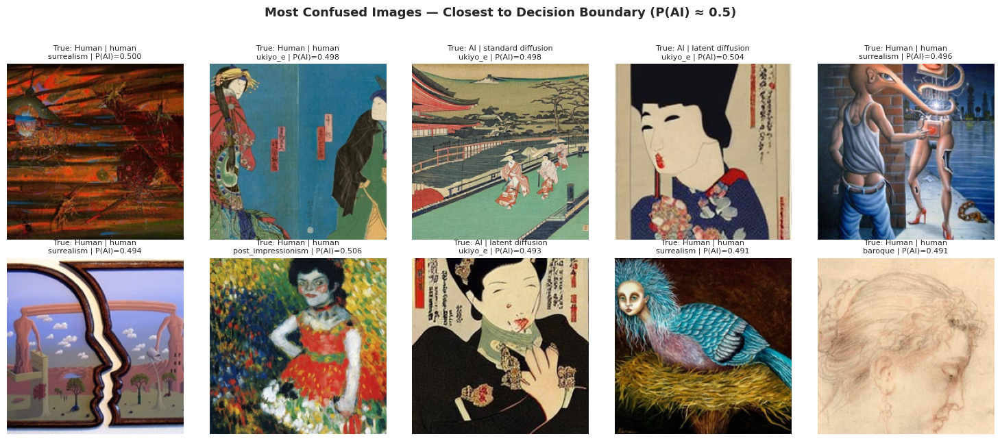

Saved → /kaggle/working/figures/12_most_confused.png
Art styles in the confused set:
style
surrealism            4
ukiyo_e               4
post_impressionism    1
baroque               1

Sources in the confused set:
source
human                 7
latent_diffusion      2
standard_diffusion    1


In [14]:
most_confused = test_meta.nsmallest(N_SHOW, 'distance')
show_image_grid(
    most_confused['path'].tolist(),
    [f"True: {'AI' if r.label==1 else 'Human'} | {r.source.replace('_',' ')}\n"
     f"{r.style} | P(AI)={r.p_ai:.3f}"
     for _, r in most_confused.iterrows()],
    'Most Confused Images — Closest to Decision Boundary (P(AI) ≈ 0.5)',
    f'{FIG_DIR}/12_most_confused.png'
)

# Style breakdown of confused images
print('Art styles in the confused set:')
print(most_confused['style'].value_counts().to_string())
print()
print('Sources in the confused set:')
print(most_confused['source'].value_counts().to_string())

## Embedding Dimension Probing

Top 10 most important embedding dimensions:
Rank    Dim     Weight  Direction
----------------------------------------
   1    198     9.4219  → AI
   2    491     8.8877  → AI
   3    360    -8.4887  → Human
   4    339    -8.4549  → Human
   5      0     8.3358  → AI
   6    117     8.2403  → AI
   7    348    -7.9068  → Human
   8    450     7.6028  → AI
   9     15     7.4391  → AI
  10    380     7.2560  → AI


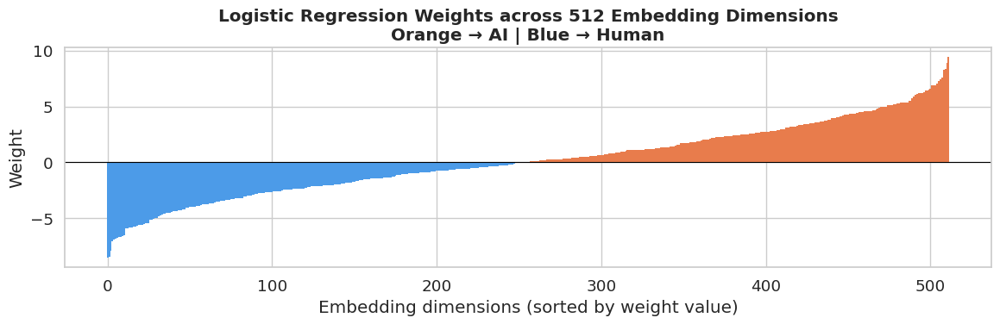

In [15]:

weights = clf.coef_[0]

top_dims = np.argsort(np.abs(weights))[::-1][:10]

print('Top 10 most important embedding dimensions:')
print(f'{"Rank":>4} {"Dim":>6} {"Weight":>10}  Direction')
print('-' * 40)
for rank, dim in enumerate(top_dims, 1):
    w   = weights[dim]
    dir = 'AI' if w > 0 else 'Human'
    print(f'{rank:>4} {dim:>6} {w:>10.4f}  → {dir}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(weights)), np.sort(weights),
       color=['#E87C4C' if w > 0 else '#4C9BE8' for w in np.sort(weights)],
       width=1.0, edgecolor='none')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Embedding dimensions (sorted by weight value)')
ax.set_ylabel('Weight')
ax.set_title('Logistic Regression Weights across 512 Embedding Dimensions\n'
             'Orange → AI | Blue → Human',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/13_weight_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

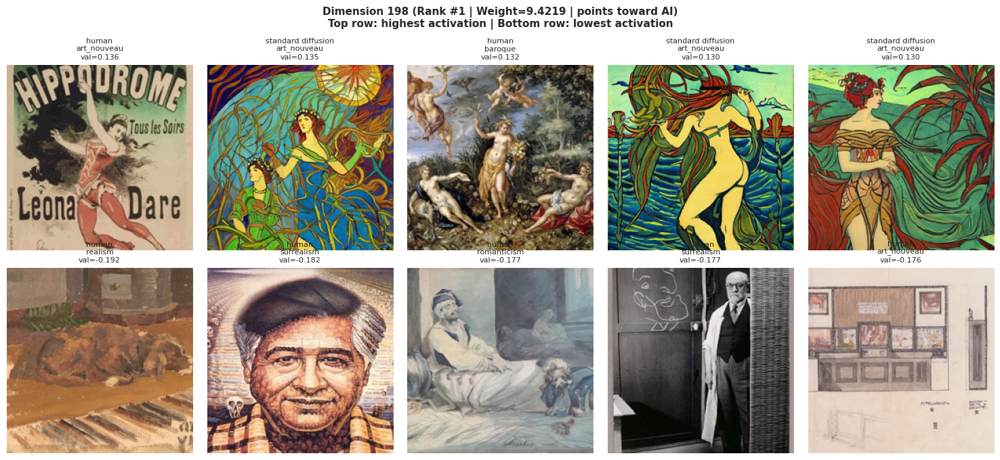

Saved → /kaggle/working/figures/14_dim_probe_rank1_dim198.png


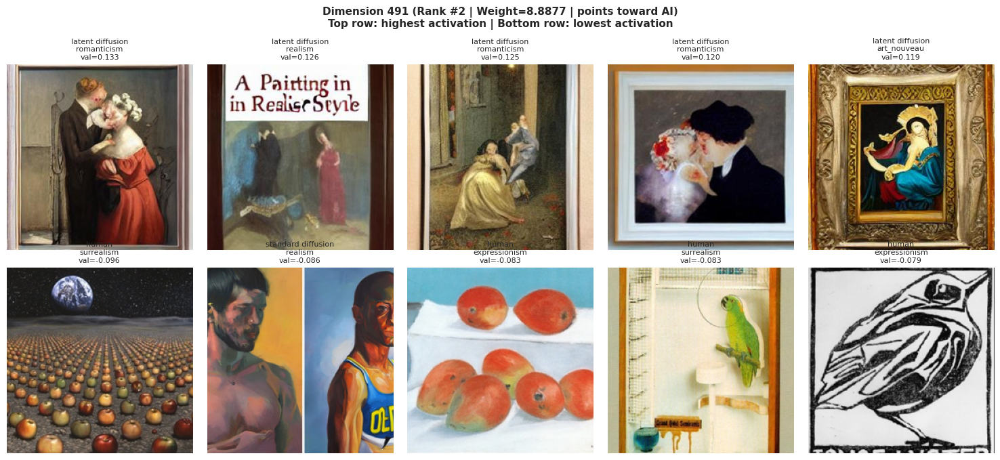

Saved → /kaggle/working/figures/14_dim_probe_rank2_dim491.png


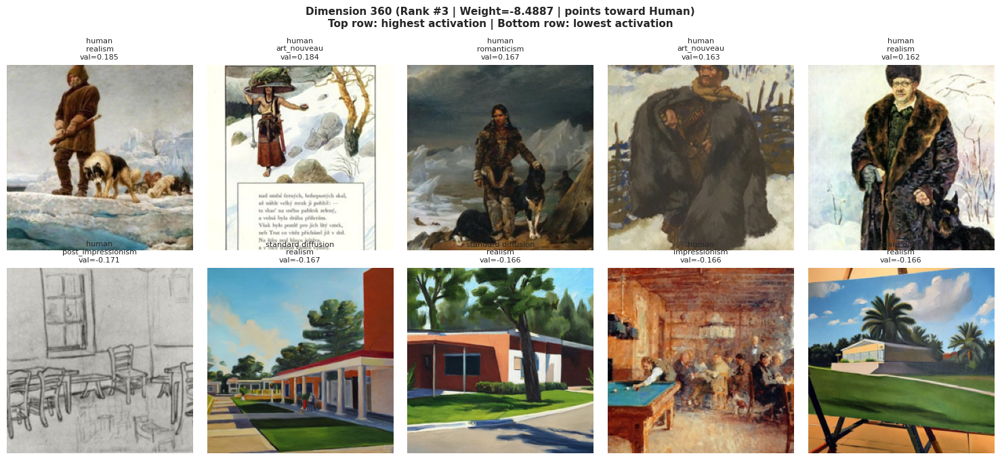

Saved → /kaggle/working/figures/14_dim_probe_rank3_dim360.png


In [16]:

N_IMAGES = 5

for rank, dim in enumerate(top_dims[:3], 1):
    dim_vals  = E[:, dim]  
    direction = 'AI' if weights[dim] > 0 else 'Human'

    top_idx    = np.argsort(dim_vals)[::-1][:N_IMAGES]   
    bottom_idx = np.argsort(dim_vals)[:N_IMAGES]          

    fig, axes = plt.subplots(2, N_IMAGES, figsize=(N_IMAGES * 3, 7))
    fig.suptitle(f'Dimension {dim} (Rank #{rank} | Weight={weights[dim]:.4f} | '
                 f'points toward {direction})\n'
                 f'Top row: highest activation | Bottom row: lowest activation',
                 fontsize=11, fontweight='bold')

    for col, idx in enumerate(top_idx):
        row_data = meta.iloc[idx]
        try:
            img = Image.open(row_data['path']).convert('RGB').resize((224, 224))
            axes[0, col].imshow(img)
        except Exception:
            axes[0, col].set_facecolor('#eee')
        axes[0, col].set_title(f"{row_data['source'].replace('_',' ')}\n"
                                f"{row_data['style']}\nval={dim_vals[idx]:.3f}",
                                fontsize=8)
        axes[0, col].axis('off')

    for col, idx in enumerate(bottom_idx):
        row_data = meta.iloc[idx]
        try:
            img = Image.open(row_data['path']).convert('RGB').resize((224, 224))
            axes[1, col].imshow(img)
        except Exception:
            axes[1, col].set_facecolor('#eee')
        axes[1, col].set_title(f"{row_data['source'].replace('_',' ')}\n"
                                f"{row_data['style']}\nval={dim_vals[idx]:.3f}",
                                fontsize=8)
        axes[1, col].axis('off')

    plt.tight_layout()
    save_path = f'{FIG_DIR}/14_dim_probe_rank{rank}_dim{dim}.png'
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')

## Summary of explainability findings

In [17]:
confused_styles  = most_confused['style'].value_counts()
confused_sources = most_confused['source'].value_counts()

print()
print('1. ATTENTION MAPS')
print('   → Note: do human and AI images show different attention patterns?')
print()
print('2. CONFIDENCE ANALYSIS')
print(f'   → Most confused images style breakdown:')
for style, count in confused_styles.items():
    print(f'      {style}: {count}')
print(f'   → Most confused images source breakdown:')
for src, count in confused_sources.items():
    print(f'      {src}: {count}')
print()
print('3. DIMENSION PROBING')
print(f'   → Top 3 most important dimensions: {top_dims[:3].tolist()}')
print(f'   → Weight range: [{weights.min():.3f}, {weights.max():.3f}]')
print(f'   → Sparsity (|w| < 0.01): {(np.abs(weights) < 0.01).mean()*100:.1f}% of dims near zero')
print()




1. ATTENTION MAPS
   → Note: do human and AI images show different attention patterns?

2. CONFIDENCE ANALYSIS
   → Most confused images style breakdown:
      surrealism: 4
      ukiyo_e: 4
      post_impressionism: 1
      baroque: 1
   → Most confused images source breakdown:
      human: 7
      latent_diffusion: 2
      standard_diffusion: 1

3. DIMENSION PROBING
   → Top 3 most important dimensions: [198, 491, 360]
   → Weight range: [-8.489, 9.422]
   → Sparsity (|w| < 0.01): 0.2% of dims near zero

